In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv(r'/content/placementdata.csv')

In [ ]:
dataset.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [ ]:
dataset.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


Obsevations:-

The dataset does not have any missing values.

In [ ]:
dataset.duplicated().sum()

np.int64(0)

Observations:-

The dataset also does not contain any duplicate rows.

In [ ]:
dataset['PlacementStatus'].value_counts()

,count
PlacementStatus,
NotPlaced,5803
Placed,4197


Observations:-

The dataset is approximately balanced and shows almost a 40-60 split of placed and not placed students.

In [ ]:
#function to normalize placement as percentage and compare it using graphs
#function for categorical columns

def bar_graph(column, kind="bar"):
    table = pd.crosstab(
        dataset[column],
        dataset["PlacementStatus"],
        normalize="index"
    ) * 100

    table.plot(kind=kind, figsize=(8, 5))

    plt.title(f"Placement Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Percentage")
    plt.legend(title="Placement Status")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return dataset.groupby('PlacementStatus')[column].describe()

In [ ]:
#functions for continuous columns
def box_plot(column):
    dataset.boxplot(
        column=column,
        by='PlacementStatus',
        figsize=(8,5)
    )

    plt.title(f"{column.replace('_', ' ').title()} vs Placement Status")
    plt.suptitle("")
    plt.xlabel("Placement Status")
    plt.ylabel(column.replace('_', ' ').title())
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    return dataset.groupby('PlacementStatus')[column].describe()

In [ ]:
def kde_plot(column):
    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=dataset,
        x=column,
        hue='PlacementStatus',
        fill=True,
        common_norm=False,
        alpha=0.6
    )
    plt.title(f'KDE Plot of {column.replace("_", " ").title()} by Placement Status')
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel('Density')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    print(f"\nDescriptive statistics for {column.replace('_', ' ').title()} by Placement Status:")
    return dataset.groupby('PlacementStatus')[column].describe()

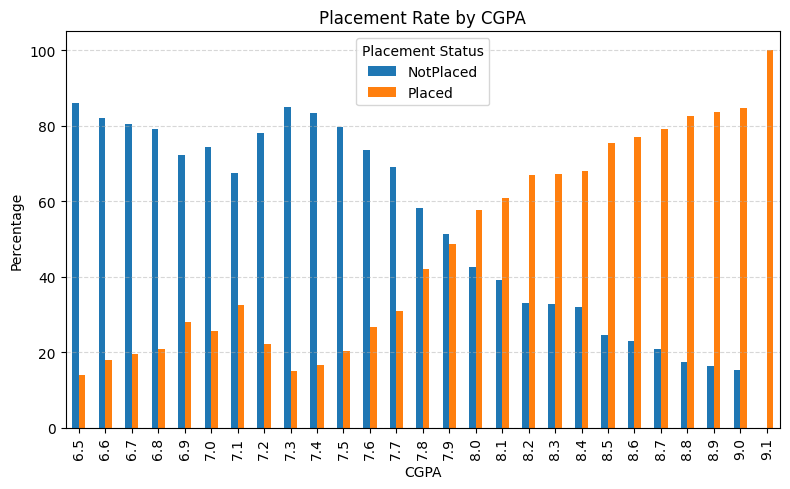

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
NotPlaced,5803.0,7.467672,0.602653,6.5,7.0,7.5,7.9,9.0
Placed,4197.0,8.016488,0.547213,6.5,7.7,8.2,8.4,9.1


In [ ]:
bar_graph('CGPA')

Observations:-

The graph suggests that having CGPA above 8.0 greatly enhances the student's chances of being placed and shows linear behaviour as the more CGPA increases, the more the placement chances increases.

From this, we can infer that companies generally tend to hire those who do well academically as they are more knowledgeable than those with less CGPA.

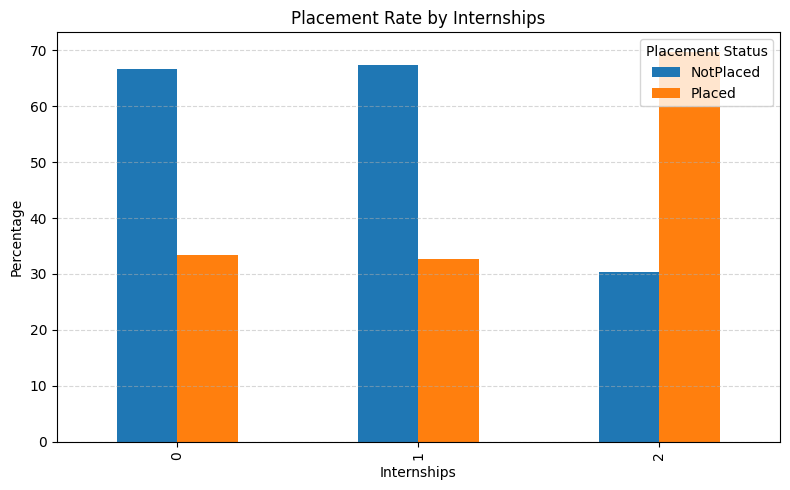

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
NotPlaced,5803.0,0.901775,0.589172,0.0,1.0,1.0,1.0,2.0
Placed,4197.0,1.253038,0.710683,0.0,1.0,1.0,2.0,2.0


In [ ]:
bar_graph('Internships')

Observations:-

This graph shows having more than 1 internships enhances the chances of being placed more than having 0 or 1 internships.

We can say that companies generally prefer students with more practical experience from this.

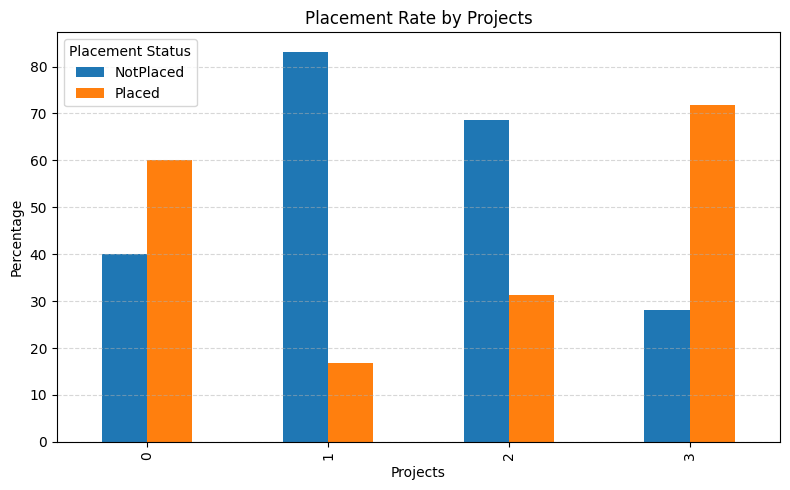

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
NotPlaced,5803.0,1.675857,0.774384,0.0,1.0,1.0,2.0,3.0
Placed,4197.0,2.511556,0.748798,0.0,2.0,3.0,3.0,3.0


In [ ]:
bar_graph('Projects')

In [ ]:
#check value count because graph shows irregular behaviour for only one catgory
print(dataset["Projects"].value_counts().sort_index())

Projects
0      30
1    3547
2    2550
3    3873
Name: count, dtype: int64


Observations:-

This graph shows a great positive trend as increasing the number of projects exponentially enhances placement chances.

Here, we can ignore the outlier of 0 projects as it has almost an insignificant number of students in that category compared to the rest and hence can be highly misleading.

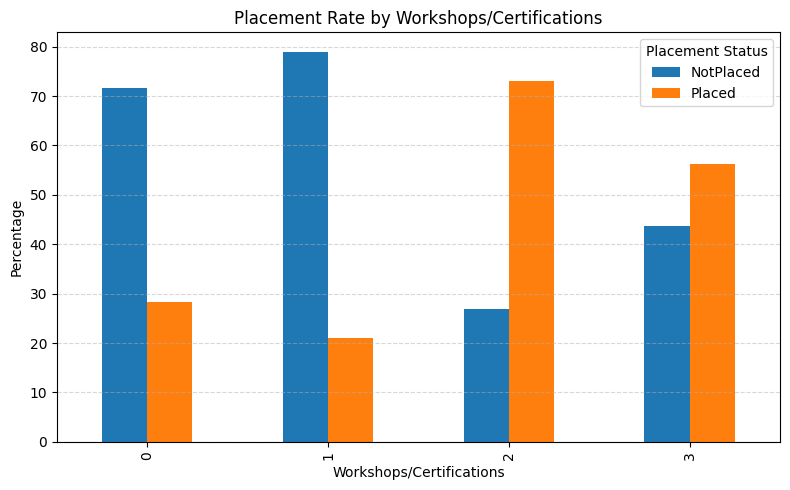

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
NotPlaced,5803.0,0.73462,0.793731,0.0,0.0,1.0,1.0,3.0
Placed,4197.0,1.39838,0.906484,0.0,0.0,2.0,2.0,3.0


In [ ]:
bar_graph('Workshops/Certifications')

Observations:-

We see that having 2 or more workshops/certifications greatly help students in being placed than those that have less than 2.

This suggests that companies are looking for students with certificates, proving that they have knowledge and experience in that relevant field.

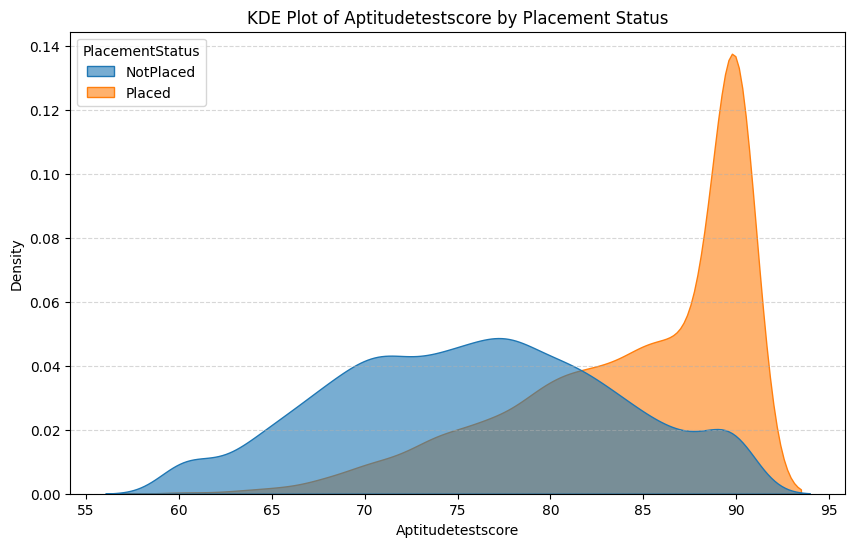


Descriptive statistics for Aptitudetestscore by Placement Status:


,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
NotPlaced,5803.0,75.829399,7.482936,60.0,70.0,76.0,81.0,90.0
Placed,4197.0,84.455802,6.168724,60.0,81.0,86.0,90.0,90.0


In [ ]:
kde_plot('AptitudeTestScore')

Observations:-

The kde plot suggests that students with higher aptitude score have better chances of being placed.

From this, we can infer that companies want students with higher aptitudes as it enhances their problem solving skills and helps them understand new topics better.

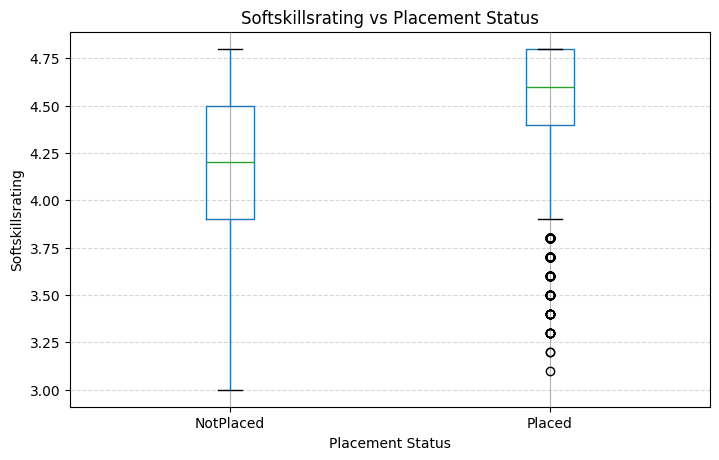

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
NotPlaced,5803.0,4.174393,0.407034,3.0,3.9,4.2,4.5,4.8
Placed,4197.0,4.530760,0.317731,3.1,4.4,4.6,4.8,4.8


In [ ]:
box_plot('SoftSkillsRating')

Observations:-

The box plot indicates that students with higher soft skills ratings have a significantly better chance of being placed. The median soft skills rating for placed students is higher and the distribution is shifted towards higher values compared to not placed students.

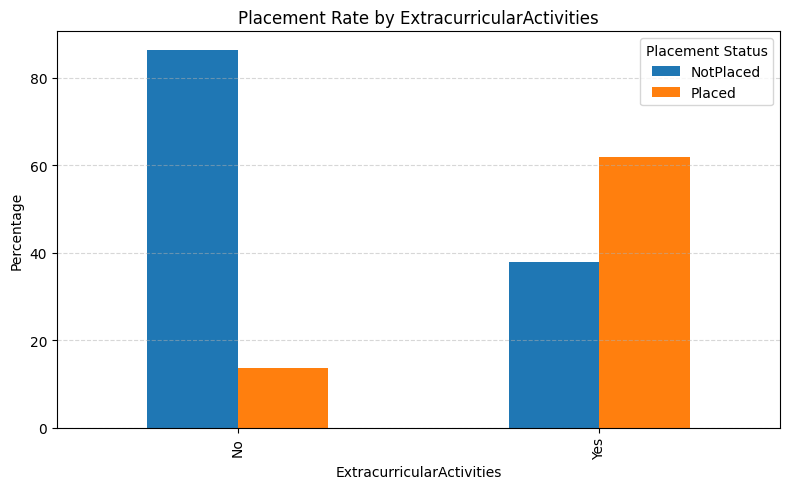

,count,unique,top,freq
PlacementStatus,,,,
NotPlaced,5803,2,No,3579
Placed,4197,2,Yes,3630


In [ ]:
bar_graph('ExtracurricularActivities')

Observations:-

The bar graph suggests that students involved in extracurricular activities have a higher placement rate than those who do do not participate in it.

This could imply that participation in such activities contributes positively to a student's profile, making them more attractive to companies.

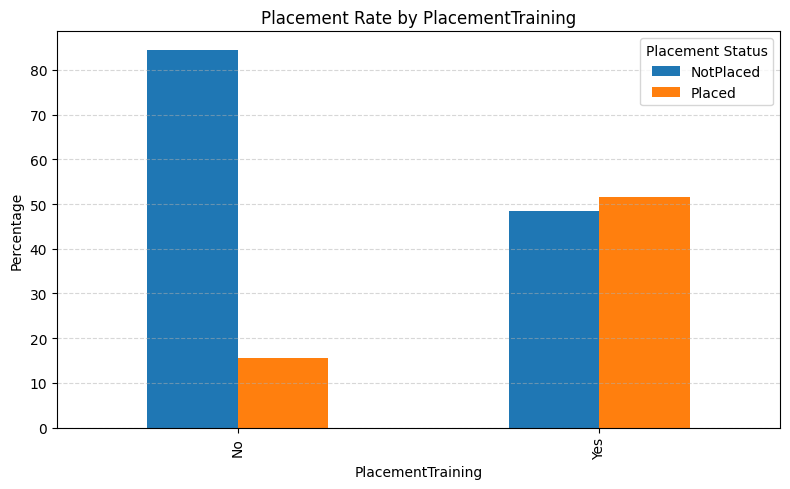

,count,unique,top,freq
PlacementStatus,,,,
NotPlaced,5803,2,Yes,3539
Placed,4197,2,Yes,3779


In [ ]:
bar_graph('PlacementTraining')

Observations:-

This graph clearly shows that students who underwent placement training have a much higher chance of being placed compared to those who did not.

This highlights the importance of specific training for placement success as students gain more experience in the placement process.

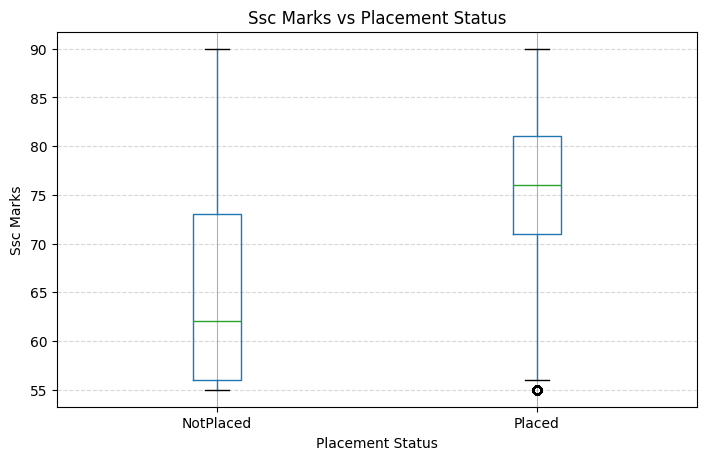

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
NotPlaced,5803.0,64.992590,9.525711,55.0,56.0,62.0,73.0,90.0
Placed,4197.0,74.920658,8.750685,55.0,71.0,76.0,81.0,90.0


In [ ]:
box_plot('SSC_Marks')

Observations:-

The box plot reveals that students with higher SSC marks tend to have a better chance of placement.

The median SSC marks for placed students are noticeably higher than for not placed students, indicating that academic performance at an earlier stage can also be a factor.

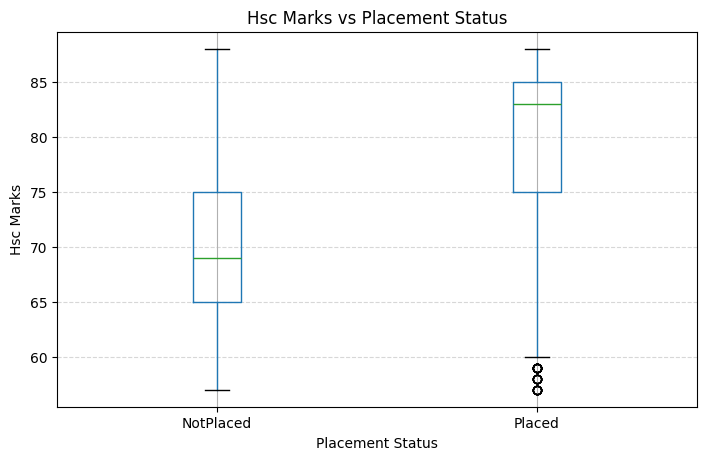

,count,mean,std,min,25%,50%,75%,max
PlacementStatus,,,,,,,,
NotPlaced,5803.0,70.665346,7.742229,57.0,65.0,69.0,75.0,88.0
Placed,4197.0,79.805575,7.629457,57.0,75.0,83.0,85.0,88.0


In [ ]:
box_plot('HSC_Marks')

Observations:-

Similar to SSC marks, the box plot for HSC marks demonstrates that higher marks are associated with a greater likelihood of placement.

This reinforces the idea that consistent academic achievement throughout schooling is a positive indicator for placement success.

In [ ]:
#copy of dataset for correlation analysis
dataset_corr = dataset.copy()

dataset_corr = dataset_corr.drop("StudentID", axis=1)

<Axes: >

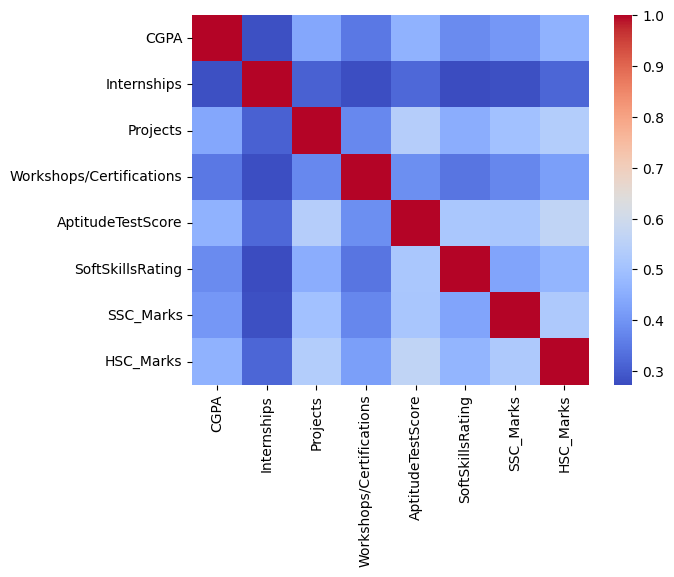

In [ ]:
corr = dataset_corr.corr(numeric_only=True)

sns.heatmap(corr,
            cmap='coolwarm')

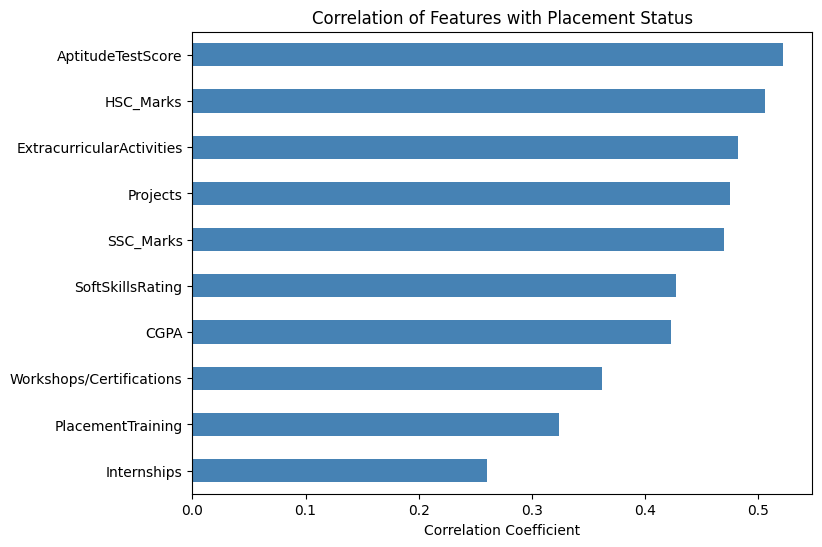

In [ ]:
dataset_corr["PlacementStatus"] = dataset_corr["PlacementStatus"].map({
    "Placed":1,
    "NotPlaced":0
})

dataset_corr["ExtracurricularActivities"] = dataset_corr["ExtracurricularActivities"].map({
    "Yes":1,
    "No":0
})

dataset_corr["PlacementTraining"] = dataset_corr["PlacementTraining"].map({
    "Yes":1,
    "No":0
})

corr = dataset_corr.corr(numeric_only=True)

corr_with_target = corr["PlacementStatus"].drop("PlacementStatus")

corr_with_target.sort_values(ascending=True).plot(
    kind="barh",
    figsize=(8,6),
    color="steelblue"
)

plt.title("Correlation of Features with Placement Status")
plt.xlabel("Correlation Coefficient")
plt.show()

Correlation Analysis and Key Insights:-

* The correlation analysis indicates that Aptitude Test Score has the strongest positive association with placement status.
* Academic performance in HSC and SSC, project experience, extracurricular activities, and soft skills also demonstrate moderate positive correlations with placement.
* Internships and placement training show weaker positive correlations.

These findings suggest that both academic performance and practical skills contribute greatly to placement status in this dataset.